# Correlación entre acciones del S&P 500

### Entregable 1 — Definición del problema, fuentes de datos y repositorio reproducible

**Materia:** Datos Masivos
**Integrantes:** Franco Rissotto · Miguel Herrera · Octavio de la Mora · Paolo del Valle

---

Este notebook demuestra que el proyecto tiene una pregunta clara, fuentes de datos reales
y una primera implementación que cualquier persona puede descargar y ejecutar.

## 0. Preparación del entorno

La siguiente celda resuelve un problema práctico: cuando Jupyter abre un notebook que vive
en `notebooks/`, Python se queda "parado" dentro de esa carpeta y no encuentra el código de
`src/`, que está un nivel arriba.

En lugar de escribir una ruta fija —que solo funcionaría en la computadora de un integrante—
la celda **sube por el árbol de carpetas hasta encontrar `src/`**. Así funciona igual si el
notebook se ejecuta desde `notebooks/`, desde la raíz del proyecto, o desde cualquier carpeta
donde alguien haya descomprimido el repositorio.

In [1]:
import sys
from pathlib import Path

# Sube por el arbol de carpetas hasta encontrar src/. No depende de la ruta
# personal de ningun integrante ni de donde se haya clonado el repositorio.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Raiz del proyecto detectada: {ROOT}")

Raiz del proyecto detectada: /Users/franco.rissottoo/School/Datos-Masivos/datos-masivos-correlacion-sp500


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import analysis, config, quality, returns
from src.data import get_fred_series, get_prices, get_sp500_constituents

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 25)

# Paleta del proyecto. Validada para vision con daltonismo.
AZUL = "#2a78d6"      # categoria 1
NARANJA = "#eb6834"   # categoria 2
TINTA = "#0b0b0b"
TINTA_SUAVE = "#52514e"
RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#cccccc",
    "axes.labelcolor": TINTA_SUAVE,
    "text.color": TINTA,
    "xtick.color": TINTA_SUAVE,
    "ytick.color": TINTA_SUAVE,
    "axes.grid": True,
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.8,
    "figure.facecolor": "white",
})

print("Librerias cargadas.")

Librerias cargadas.


---

## 1. Definición del problema

### El problema

Cuando se construye un portafolio de inversión, el riesgo total **no es la suma de los riesgos
individuales**. Depende de cómo se mueven los activos *entre sí*. Dos acciones que suben y bajan
al mismo tiempo no diversifican nada: es como tener una sola posición del doble de tamaño.

Medir esa estructura de co-movimiento es el problema central de la gestión de riesgo, y es lo
que hacen plataformas como Aladdin de BlackRock. Pero la correlación observada entre dos acciones
mezcla dos cosas distintas: el hecho de que *todo el mercado* se mueve junto, y un vínculo real
entre las dos empresas.

### Por qué es relevante

- Un portafolio que **parece** diversificado (30 acciones distintas) puede estar concentrado en
  un solo tipo de riesgo si esas 30 se mueven igual.
- La correlación **no es estable**: cambia con el tiempo y tiende a aumentar en las crisis,
  justo cuando la diversificación más se necesita.
- Es un problema de datos masivos por naturaleza: con 500 acciones hay **más de 124,000 pares**
  que evaluar, y el número crece con el cuadrado del universo.

### Pregunta concreta de este entregable

> **¿Las acciones del mismo sector GICS están más correlacionadas entre sí que con acciones de
> otros sectores, y qué tan grande es esa diferencia?**

Es una pregunta deliberadamente sencilla. Cumple dos funciones: responde algo verificable con
datos, y sirve como **prueba de validez del pipeline**. Si los datos no mostraran que dos bancos
se mueven más parecido entre sí que un banco y una aerolínea, sería señal de que hay un error en
la extracción o en el procesamiento.

## 2. Usuario o interesado

| Usuario | Qué decisión toma con esto |
|---|---|
| **Analista de riesgo de un fondo** | Detectar concentración oculta: un portafolio con muchas posiciones distintas pero alta correlación interna no está diversificado |
| **Asesor financiero** | Justificar ante un cliente por qué agregar una acción más del mismo sector aporta poco, y cuánto aportaría una de otro sector |
| **Estudiante o investigador** | Punto de partida para modelos de factores, construcción de portafolios y análisis de contagio |

**Decisión concreta que habilita:** ante dos candidatos para agregar a un portafolio, elegir el
que menos se parezca a lo que ya se tiene. Este entregable cuantifica ese "parecerse".

## 3. Fuentes de datos

Se utilizan **tres** fuentes (la rúbrica pide al menos dos), y las tres se obtienen mediante
código: dos por API/librería y una por scraping.

| # | Fuente | Método | Variables principales | Periodo | Formato |
|---|---|---|---|---|---|
| 1 | **Yahoo Finance** vía `yfinance` | Librería / API | Precio de cierre **ajustado** diario por ticker | 2015-01 a la fecha | JSON → DataFrame → Parquet |
| 2 | **Wikipedia** — lista del S&P 500 | Scraping (`requests` + `pandas.read_html`) | Ticker, empresa, sector GICS, sub-industria | Composición actual | HTML → DataFrame → Parquet |
| 3 | **FRED** (Fed de St. Louis) | API REST con llave | VIX (volatilidad), tasa del Tesoro a 10 años | 2015-01 a la fecha | JSON → DataFrame → Parquet |

**Sobre las credenciales.** FRED requiere una llave gratuita. La llave se lee de la variable de
entorno `FRED_API_KEY` (archivo `.env`, excluido del repositorio por `.gitignore`). El archivo
`.env.example` documenta qué variables hacen falta, sin exponer ningún valor. **Si la llave no
está configurada, el notebook no falla**: avisa y continúa, porque quien revise este trabajo no
tiene por qué registrarse en FRED para poder ejecutarlo.

---

## 4. Primera extracción

### 4.1 Constituyentes del S&P 500 y su sector (scraping)

In [3]:
constituyentes = get_sp500_constituents()

print(f"Dimensiones: {constituyentes.shape[0]} filas x {constituyentes.shape[1]} columnas")
print()
print("Tipos de variables:")
print(constituyentes.dtypes.to_string())
print()
print("Primeras filas:")
constituyentes.head()

Dimensiones: 503 filas x 4 columnas

Tipos de variables:
ticker             str
company         string
sector          string
sub_industry    string

Primeras filas:


,ticker,company,sector,sub_industry
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals"
2,ABBV,AbbVie,Health Care,Biotechnology
3,ABNB,Airbnb,Consumer Discretionary,"Hotels, Resorts & Cruise Lines"
4,ABT,Abbott Laboratories,Health Care,Health Care Equipment


In [4]:
print("Empresas por sector GICS:")
constituyentes["sector"].value_counts().to_frame("n_empresas")

Empresas por sector GICS:


,n_empresas
sector,
Industrials,83
Financials,76
Information Technology,73
Health Care,59
Consumer Discretionary,47
Consumer Staples,34
Utilities,31
Real Estate,30
Materials,25


> **Nota sobre la traducción de símbolos.** Wikipedia escribe los tickers de clases de acción con
> punto (`BRK.B`, `BF.B`) y Yahoo Finance los escribe con guion (`BRK-B`, `BF-B`). Sin esa
> traducción, esos tickers regresan vacíos de Yahoo **sin lanzar ningún error** y desaparecen del
> análisis en silencio. La función `to_yahoo_ticker()` en `src/data.py` se encarga de eso.

### 4.2 Precios diarios ajustados (API)

Se descargan **precios ajustados** (`auto_adjust=True`), corregidos por splits y dividendos. Con
el precio de cierre crudo, un split 4:1 aparecería como una caída de −75% en un solo día y
contaminaría toda la matriz de correlación.

In [5]:
precios = get_prices(constituyentes["ticker"].tolist())

print(f"Dimensiones: {precios.shape[0]} dias x {precios.shape[1]} tickers")
print(f"Total de observaciones: {precios.shape[0] * precios.shape[1]:,}")
print(f"Periodo: {precios.index.min().date()} a {precios.index.max().date()}")
print()
print(f"Tipo de dato: {precios.dtypes.unique()[0]}   |   Indice: {type(precios.index).__name__}")
print()
print("Primeras filas (primeros 6 tickers):")
precios.iloc[:5, :6]

Dimensiones: 2934 dias x 503 tickers
Total de observaciones: 1,475,802
Periodo: 2015-01-02 a 2026-09-02

Tipo de dato: float64   |   Indice: DatetimeIndex

Primeras filas (primeros 6 tickers):


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL
date,,,,,,
2015-01-02,36.899395,24.171757,41.119221,NaN,35.754196,18.539352
2015-01-05,36.207985,23.490797,40.345413,NaN,35.762165,18.428413
2015-01-06,35.643944,23.493017,40.145706,NaN,35.356045,18.469618
2015-01-07,36.116989,23.822435,41.768246,NaN,35.642723,18.577387
2015-01-08,37.199604,24.737745,42.205086,NaN,36.375324,18.900694


### 4.3 Series macro de FRED (API con credenciales)

In [6]:
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    macro = get_fred_series()

for aviso in avisos:
    print(f"AVISO: {aviso.message}")

if macro.empty:
    print("\nNo se cargaron datos macro. El resto del analisis continua sin ellos.")
else:
    print(f"\nDimensiones: {macro.shape}")
    print(macro.tail(3))

AVISO: [FRED] No hay FRED_API_KEY ni respaldo disponible. Se devuelve una tabla vacia; el resto del analisis continua sin datos macro.

No se cargaron datos macro. El resto del analisis continua sin ellos.


---

## 5. Diagnóstico inicial

Antes de analizar hay que auditar. Una matriz de correlación no avisa cuando está calculada sobre
datos rotos: devuelve números que parecen razonables.

### 5.1 Estructura general, nulos y duplicados

In [7]:
quality.structure_summary(precios).to_frame("valor")

,valor
filas (dias de mercado),2934
columnas (tickers),503
observaciones totales,1475802
valores faltantes,54479
% faltantes,3.69
fechas duplicadas,0
tickers duplicados,0
fecha inicial,2015-01-02
fecha final,2026-09-02


In [8]:
reporte = quality.per_ticker_report(precios)

print("Tickers con MENOS historia (los mas recientes en entrar al indice):")
reporte.head(10)

Tickers con MENOS historia (los mas recientes en entrar al indice):


,n_obs,n_missing,first_date,last_date,pct_missing,suficiente_historia
ticker,,,,,,
HONA,56,2878,2026-06-15,2026-09-02,98.09,False
FDXF,69,2865,2026-05-27,2026-09-02,97.65,False
Q,214,2720,2025-10-27,2026-09-02,92.71,False
SNDK,390,2544,2025-02-13,2026-09-02,86.71,False
GEV,611,2323,2024-03-27,2026-09-02,79.18,False
SOLV,612,2322,2024-03-26,2026-09-02,79.14,False
RDDT,615,2319,2024-03-21,2026-09-02,79.04,False
VLTO,731,2203,2023-10-04,2026-09-02,75.09,False
KVUE,836,2098,2023-05-04,2026-09-02,71.51,False


**Interpretación.** Los faltantes no son datos "sucios": son empresas que **todavía no cotizaban**
al inicio del periodo. `RDDT` (Reddit) salió a bolsa en 2024; `GEV` (GE Vernova) se escindió de
General Electric ese mismo año. El tratamiento correcto es distinto al de un dato corrupto.

In [9]:
huecos = quality.calendar_gaps(precios)
print(f"Huecos de mas de 5 dias en el calendario de mercado: {len(huecos)}")
huecos.head()

Huecos de mas de 5 dias en el calendario de mercado: 0


,fecha,dias_sin_datos


### 5.2 Construcción del panel balanceado

Un **panel balanceado** es una tabla rectangular sin huecos: solo conserva los días en que
*todos* los tickers tienen precio.

Aquí hay una sutileza que cuesta caro si se ignora: **en un panel balanceado, la longitud la impone
el ticker sobreviviente más joven**. Si se admite una empresa que salió a bolsa en 2024, todas las
demás pierden la historia anterior a esa fecha.

Se midió el intercambio sobre los datos reales:

| Mínimo exigido | Empresas | Días del panel | % de historia |
|---|---|---|---|
| 500 | 499 | 609 | 20.8% |
| 1,000 | 493 | 1,158 | 39.5% |
| 2,000 | 475 | 2,030 | 69.2% |
| **2,900** | **459** | **2,932** | **99.9%** |
| 2,934 | 457 | 2,934 | 100.0% |

Exigir historia casi completa cuesta 44 empresas (9% del universo) y a cambio **multiplica por
cinco** la historia disponible. Se eligió 2,900 en vez de 2,934 para tolerar acciones con uno o
dos días suspendidos.

**Lo que deliberadamente NO se hace:** rellenar hacia adelante (`ffill`). Eso inventaría días con
rendimiento de 0% que nunca ocurrieron y sesgaría todas las correlaciones hacia abajo.

In [10]:
panel, bitacora = returns.build_balanced_panel(precios)

for clave, valor in bitacora.items():
    if clave != "lista_descartados":
        print(f"{clave:>25}: {valor}")

print()
print("Tickers descartados por historia insuficiente:")
print(", ".join(bitacora["lista_descartados"]))

        tickers_iniciales: 503
      tickers_descartados: 44
          tickers_finales: 459
          filas_iniciales: 2934
        filas_descartadas: 2
            filas_finales: 2932

Tickers descartados por historia insuficiente:
ABNB, APP, CARR, CEG, COIN, CRWD, CTVA, CVNA, DASH, DDOG, DELL, DOW, EXE, FDXF, FOX, FOXA, FTV, GDDY, GEHC, GEV, HONA, HOOD, HPE, HWM, INVH, IR, KHC, KVUE, LITE, MRNA, OTIS, PLTR, PYPL, Q, RDDT, SNDK, SOLV, TTD, UBER, VICI, VLTO, VRT, VST, XYZ


### 5.3 Rendimientos logarítmicos

**Por qué no se correlacionan precios directamente.** Una serie de precios no es estacionaria: su
media y su varianza cambian con el tiempo porque tiene tendencia. Correlacionar los precios de dos
empresas que subieron en la última década da ~0.95, y eso **no significa que se muevan juntas**:
significa que las dos subieron. Es correlación espuria.

La transformación estándar es el rendimiento logarítmico:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Los rendimientos son aproximadamente estacionarios, aditivos en el tiempo y simétricos entre
subidas y bajadas.

In [11]:
rendimientos = returns.to_log_returns(panel)

print(f"Rendimientos: {rendimientos.shape[0]} dias x {rendimientos.shape[1]} tickers")
print()
print("Estadisticas descriptivas (primeros 6 tickers):")
rendimientos.iloc[:, :6].describe().round(4)

Rendimientos: 2931 dias x 459 tickers

Estadisticas descriptivas (primeros 6 tickers):


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN
count,2931.0000,2931.0000,2931.0000,2931.0000,2931.0000,2931.0000
mean,0.0005,0.0009,0.0006,0.0004,0.0006,0.0003
std,0.0174,0.0181,0.0169,0.0151,0.0166,0.0173
min,-0.1167,-0.1377,-0.1774,-0.1058,-0.1848,-0.1980
25%,-0.0082,-0.0074,-0.0070,-0.0067,-0.0064,-0.0071
50%,0.0010,0.0010,0.0011,0.0006,0.0011,0.0011
75%,0.0097,0.0100,0.0089,0.0084,0.0084,0.0085
max,0.1559,0.1426,0.1290,0.1038,0.1429,0.1210


### 5.4 Detección de datos corruptos

Los rendimientos extremos requieren criterio: algunos son eventos reales que **deben conservarse**,
y otros son errores de la fuente que deben excluirse.

In [12]:
extremos = quality.find_extreme_returns(rendimientos)
print(f"Movimientos diarios mayores a +/-50%: {len(extremos)}")
extremos.head(12)

Movimientos diarios mayores a +/-50%: 20


,date,ticker,log_return
4,2020-03-09,APA,-0.773593
8,2024-04-11,GL,-0.758010
7,2020-03-09,TRGP,-0.753054
2,2019-01-14,PCG,-0.741483
6,2020-03-09,OXY,-0.734257
13,2026-07-20,MNST,-0.714397
15,2026-07-31,MNST,-0.706238
17,2026-08-06,MNST,-0.696328
19,2026-08-11,MNST,-0.685430
14,2026-07-23,MNST,0.670845


In [13]:
sospechosos = quality.flag_suspicious_tickers(rendimientos)
sospechosos

,n_eventos_extremos,sospechoso
ticker,,
MNST,7,True
PCG,2,False
APA,1,False
BLDR,1,False
CNC,1,False
DXCM,1,False
ECHO,1,False
FANG,1,False
FISV,1,False


**Interpretación — la regla que separa un evento real de un error de datos es la frecuencia.**

*Eventos reales* (se conservan): una empresa se desploma **una vez** y no se recupera al día
siguiente.

- `PCG` el 2019-01-14: PG&E anunció bancarrota por los incendios forestales de California.
- `APA`, `OXY`, `TRGP` el 2020-03-09: guerra de precios del petróleo de Arabia Saudita coincidiendo
  con el desplome inicial de COVID-19.
- `GL` el 2024-04-11: Globe Life tras un reporte de vendedores en corto.

*Error de la fuente* (se excluye): `MNST` (Monster Beverage) tiene **siete** eventos, y su precio
oscila entre ~\$95 y ~\$47 —exactamente la mitad— en días sueltos, regresando después. Es un split
2:1 que Yahoo Finance aplica de forma inconsistente. Una empresa real no hace eso siete veces en
once años.

In [14]:
# Verificacion visual del caso MNST antes de excluirlo.
precios.loc["2026-07-15":"2026-08-07", ["MNST"]].T

date,2026-07-15,2026-07-16,2026-07-17,2026-07-20,2026-07-21,2026-07-22,2026-07-23,2026-07-24,2026-07-27,2026-07-28,2026-07-29,2026-07-30,2026-07-31,2026-08-03,2026-08-04,2026-08-05,2026-08-06,2026-08-07
Ticker,,,,,,,,,,,,,,,,,,
MNST,97.57,99.940002,97.5,47.724998,47.23,47.834999,93.559998,93.489998,95.330002,97.739998,97.230003,97.650002,48.189999,93.550003,94.18,94.459999,47.080002,90.360001


In [15]:
a_excluir = sospechosos[sospechosos["sospechoso"]].index.tolist()
print(f"Tickers excluidos por datos corruptos: {a_excluir}")

panel = panel.drop(columns=a_excluir)
rendimientos = rendimientos.drop(columns=a_excluir)

print(f"\nPanel final para el analisis: {panel.shape[0]} dias x {panel.shape[1]} tickers")
print(f"Observaciones utilizadas: {panel.shape[0] * panel.shape[1]:,}")

Tickers excluidos por datos corruptos: ['MNST']

Panel final para el analisis: 2932 dias x 458 tickers
Observaciones utilizadas: 1,342,856


### 5.5 Transformaciones que probablemente serán necesarias después

1. **Estandarizar los rendimientos** (restar media, dividir entre desviación estándar) antes de
   aplicar PCA en el Entregable 2, para que las acciones más volátiles no dominen los componentes.
2. **Remover el factor de mercado** para obtener correlaciones *residuales*: la correlación cruda
   confunde "se mueven juntas" con "todo el mercado se mueve junto".
3. **Ventanas móviles** en lugar de una sola correlación de todo el periodo, porque la correlación
   no es estable en el tiempo.
4. **Encogimiento (shrinkage) de la matriz de covarianza** para la capa de riesgo: con 458 activos
   hay ~105,000 parámetros que estimar y solo 2,931 observaciones.
5. **Alineación con las series macro** de FRED, que tienen calendario propio.

---

## 6. Primera evidencia

Ahora se responde la pregunta planteada al inicio.

In [16]:
correlacion = analysis.correlation_matrix(rendimientos)
pares = analysis.pair_table(correlacion, constituyentes)

print(f"Matriz de correlacion: {correlacion.shape[0]} x {correlacion.shape[1]}")
print(f"Pares unicos evaluados: {len(pares):,}")

Matriz de correlacion: 458 x 458
Pares unicos evaluados: 104,653


In [17]:
comparacion = analysis.sector_comparison(pares)
comparacion.round(4)

,n_pares,media,mediana,desv_est
grupo,,,,
Mismo sector,11477,0.4404,0.4259,0.1463
Distinto sector,93176,0.3164,0.3135,0.1085


In [18]:
media_intra = comparacion.loc["Mismo sector", "media"]
media_inter = comparacion.loc["Distinto sector", "media"]

print(f"Correlacion media, mismo sector    : {media_intra:.4f}")
print(f"Correlacion media, distinto sector : {media_inter:.4f}")
print(f"Diferencia                         : {media_intra - media_inter:.4f}")
print(f"El co-movimiento intra-sector es {media_intra / media_inter:.2f} veces el inter-sector.")

Correlacion media, mismo sector    : 0.4404
Correlacion media, distinto sector : 0.3164
Diferencia                         : 0.1241
El co-movimiento intra-sector es 1.39 veces el inter-sector.


### 6.1 Distribución de las correlaciones

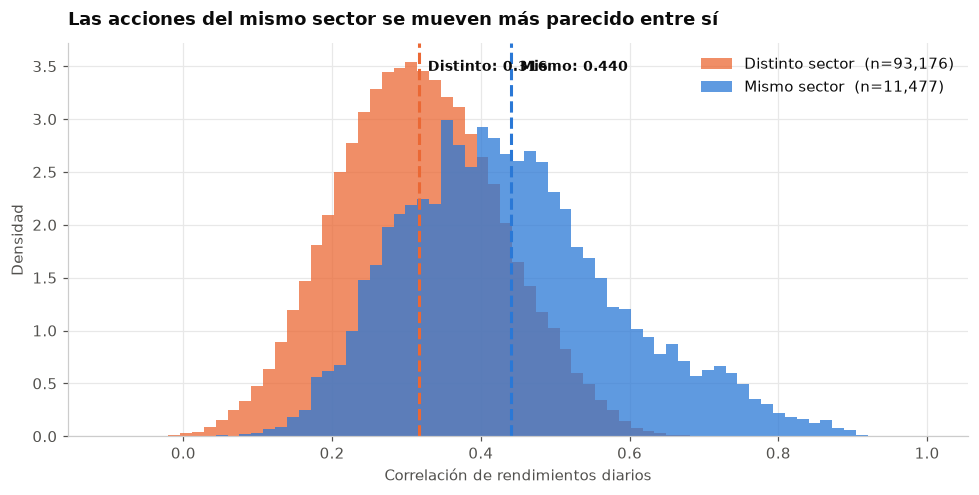

In [19]:
intra = pares.loc[pares["same_sector"], "corr"]
inter = pares.loc[~pares["same_sector"], "corr"]

fig, ax = plt.subplots(figsize=(9, 4.6))
bins = np.linspace(-0.1, 1.0, 70)

ax.hist(inter, bins=bins, density=True, color=NARANJA, alpha=0.75,
        label=f"Distinto sector  (n={len(inter):,})")
ax.hist(intra, bins=bins, density=True, color=AZUL, alpha=0.75,
        label=f"Mismo sector  (n={len(intra):,})")

for valor, color, etiqueta in [(media_inter, NARANJA, "Distinto"), (media_intra, AZUL, "Mismo")]:
    ax.axvline(valor, color=color, linewidth=2, linestyle="--")
    ax.annotate(f"{etiqueta}: {valor:.3f}", xy=(valor, ax.get_ylim()[1] * 0.93),
                xytext=(6, 0), textcoords="offset points",
                color=TINTA, fontsize=9, fontweight="bold")

ax.set_xlabel("Correlación de rendimientos diarios")
ax.set_ylabel("Densidad")
ax.set_title("Las acciones del mismo sector se mueven más parecido entre sí",
             fontsize=12, fontweight="bold", color=TINTA, loc="left", pad=12)
ax.legend(frameon=False, loc="upper right")
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "distribucion_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

Las dos distribuciones **se traslapan mucho**, y eso es tan informativo como la diferencia de
medias: pertenecer al mismo sector desplaza la correlación hacia arriba, pero no la determina. Hay
pares de sectores distintos con correlación alta y pares del mismo sector con correlación baja.

Un modelo de riesgo que asumiera "mismo sector ⇒ correlacionadas" cometería errores en ambas
direcciones.

### 6.2 Correlación promedio entre cada par de sectores

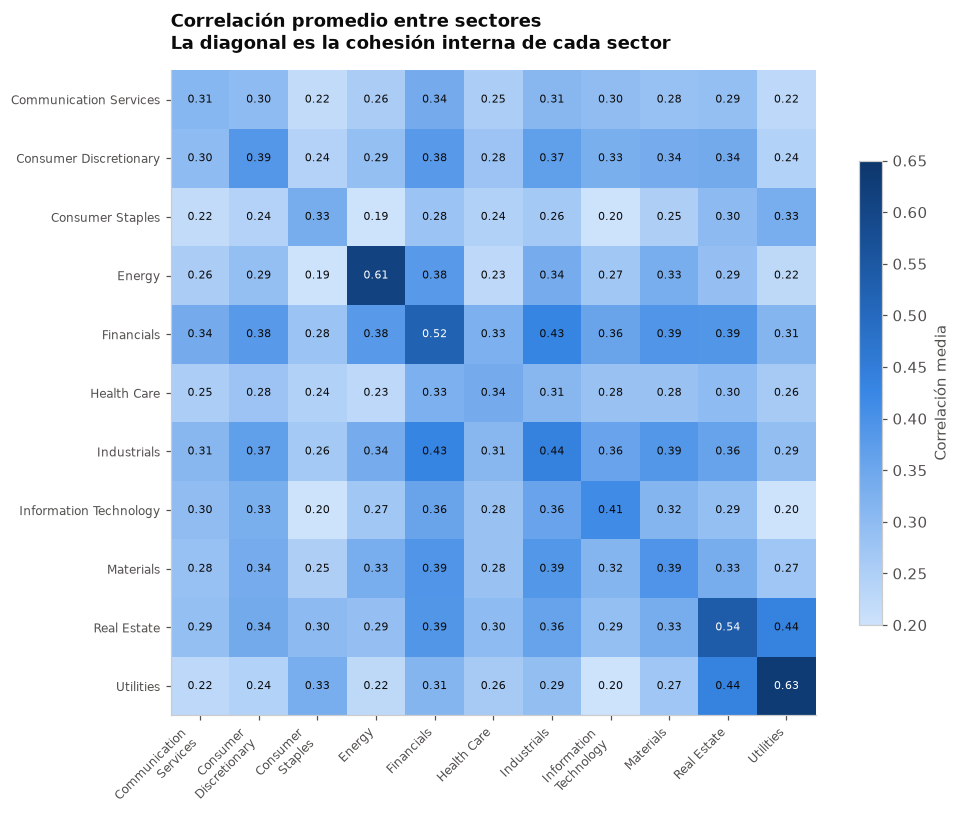

In [20]:
from matplotlib.colors import LinearSegmentedColormap

matriz_sectores = analysis.sector_matrix(pares)
rampa = LinearSegmentedColormap.from_list("azul_secuencial", RAMPA_AZUL)

fig, ax = plt.subplots(figsize=(9.5, 7.6))
imagen = ax.imshow(matriz_sectores.values, cmap=rampa, vmin=0.2, vmax=0.65)

etiquetas = [s.replace(" ", "\n") if len(s) > 14 else s for s in matriz_sectores.index]
ax.set_xticks(range(len(etiquetas)), etiquetas, fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(len(etiquetas)), matriz_sectores.index, fontsize=8)

# Etiqueta directa en cada celda: el valor no queda codificado solo por color.
for fila in range(matriz_sectores.shape[0]):
    for col in range(matriz_sectores.shape[1]):
        valor = matriz_sectores.values[fila, col]
        ax.text(col, fila, f"{valor:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if valor > 0.47 else TINTA)

ax.set_title("Correlación promedio entre sectores\nLa diagonal es la cohesión interna de cada sector",
             fontsize=12, fontweight="bold", color=TINTA, loc="left", pad=14)
ax.grid(False)
fig.colorbar(imagen, ax=ax, shrink=0.72, label="Correlación media")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "matriz_sectores.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Qué tan cohesionado está cada sector

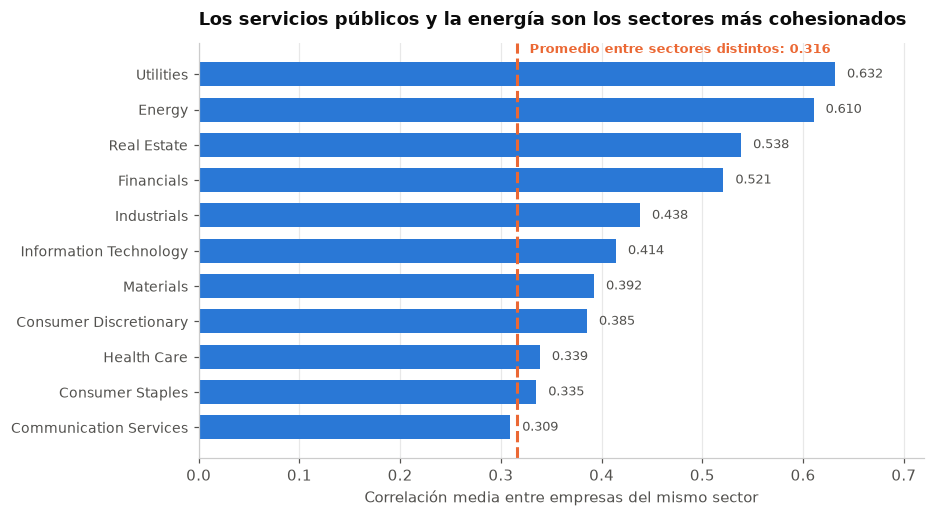

In [21]:
cohesion = analysis.sector_cohesion(pares)

fig, ax = plt.subplots(figsize=(8.6, 4.8))
orden = cohesion.sort_values("correlacion_media")
barras = ax.barh(range(len(orden)), orden["correlacion_media"], color=AZUL, height=0.68)

ax.set_yticks(range(len(orden)), orden.index, fontsize=9)
ax.set_xlabel("Correlación media entre empresas del mismo sector")
ax.set_xlim(0, 0.72)
ax.set_title("Los servicios públicos y la energía son los sectores más cohesionados",
             fontsize=12, fontweight="bold", color=TINTA, loc="left", pad=12)

for barra, valor in zip(barras, orden["correlacion_media"]):
    ax.text(valor + 0.012, barra.get_y() + barra.get_height() / 2, f"{valor:.3f}",
            va="center", fontsize=8.5, color=TINTA_SUAVE)

ax.axvline(media_inter, color=NARANJA, linewidth=2, linestyle="--")
ax.annotate(f"Promedio entre sectores distintos: {media_inter:.3f}",
            xy=(media_inter, len(orden) - 0.4), xytext=(8, 0), textcoords="offset points",
            color=NARANJA, fontsize=8.5, fontweight="bold")

ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "cohesion_sectorial.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.4 Prueba de sentido común: los pares más correlacionados

Si el pipeline es correcto, los pares con mayor correlación deberían ser empresas que cualquiera
reconocería como parecidas. Es una validación barata y muy efectiva.

In [22]:
analysis.top_pairs(pares, 12)[
    ["ticker_a", "company_a", "ticker_b", "company_b", "sector_a", "corr"]
].round(3)

,ticker_a,company_a,ticker_b,company_b,sector_a,corr
0,GOOG,Alphabet Inc. (Class C),GOOGL,Alphabet Inc. (Class A),Communication Services,0.995
1,NWS,News Corp (Class B),NWSA,News Corp (Class A),Communication Services,0.972
2,FRT,Federal Realty Investment Trust,REG,Regency Centers,Real Estate,0.912
3,UDR,"UDR, Inc.",VMRK,Vivmark Residential,Real Estate,0.912
4,FITB,Fifth Third Bancorp,RF,Regions Financial Corporation,Financials,0.908
5,AMAT,Applied Materials,LRCX,Lam Research,Information Technology,0.900
6,MET,MetLife,PRU,Prudential Financial,Financials,0.898
7,CFG,Citizens Financial Group,FITB,Fifth Third Bancorp,Financials,0.897
8,CFG,Citizens Financial Group,KEY,KeyCorp,Financials,0.896
9,ESS,Essex Property Trust,UDR,"UDR, Inc.",Real Estate,0.896


In [23]:
print("Los pares MENOS correlacionados (mayor beneficio de diversificacion):")
analysis.top_pairs(pares, 8, ascending=True)[
    ["ticker_a", "company_a", "ticker_b", "company_b", "corr"]
].round(3)

Los pares MENOS correlacionados (mayor beneficio de diversificacion):


,ticker_a,company_a,ticker_b,company_b,corr
0,CLX,Clorox,FANG,Diamondback Energy,-0.068
1,APA,APA Corporation,CLX,Clorox,-0.057
2,GIS,General Mills,MRVL,Marvell Technology,-0.051
3,GIS,General Mills,MU,Micron Technology,-0.048
4,COHR,Coherent Corp.,GIS,General Mills,-0.039
5,GIS,General Mills,WDC,Western Digital,-0.034
6,MRVL,Marvell Technology,SJM,J.M. Smucker Company (The),-0.030
7,COHR,Coherent Corp.,ED,Consolidated Edison,-0.030


---

## 7. Interpretación y conclusiones

### Respuesta a la pregunta

**Sí, y la diferencia es sustancial.** Las acciones del mismo sector GICS tienen una correlación
media de rendimientos diarios de **0.44**, frente a **0.32** entre sectores distintos: un
co-movimiento **1.39 veces mayor**, medido sobre 104,653 pares únicos y 11.6 años de historia.

### Qué valida el resultado

Los pares con mayor correlación son exactamente los que deberían ser:

- **GOOG–GOOGL (0.995)** y **NWS–NWSA (0.972)** son las dos clases de acción de la *misma empresa*.
  Que aparezcan primero confirma que el pipeline mide lo que dice medir.
- Después vienen vínculos económicos genuinos: **AMAT–LRCX** (equipo para semiconductores),
  **FITB–RF–CFG–KEY** (bancos regionales), **MET–PRU** (aseguradoras de vida),
  **FRT–REG–UDR–ESS** (fideicomisos inmobiliarios).

### Qué NO se puede concluir todavía

Este es el punto más importante para el resto del proyecto. **La correlación cruda mezcla dos
efectos distintos** y aquí no se han separado:

1. Que todo el mercado se mueve junto (el "factor de mercado").
2. Que dos empresas tienen un vínculo económico real.

Que la correlación media *entre sectores distintos* sea 0.32 —y no cerca de cero— es precisamente
la huella del factor común. La pregunta interesante, que responderemos en el Entregable 2, es
**cuánta correlación sobrevive después de quitar ese factor**.

### Limitaciones identificadas

| Limitación | Impacto |
|---|---|
| **Sesgo de supervivencia** | Se usa la composición *actual* del S&P 500. Las empresas que quebraron o salieron del índice no aparecen, lo que probablemente sesga los resultados |
| **Cobertura reducida** | 45 de 503 empresas se excluyeron por historia insuficiente y 1 por datos corruptos. El análisis cubre 458 |
| **Calidad de la fuente** | Yahoo Finance no es una API oficial. Se detectó al menos un ticker con splits mal aplicados; podría haber errores más sutiles no detectados |
| **Comparaciones múltiples** | Con 104,653 pares, cualquier prueba de significancia individual carece de sentido sin corrección por comparaciones múltiples (Benjamini-Hochberg) |
| **Correlación ≠ causalidad** | Que dos empresas se muevan juntas no implica relación causal; puede ser un tercer factor común |
| **Clases de acción duplicadas** | GOOG/GOOGL y NWS/NWSA son la misma empresa y inflan artificialmente el extremo superior |

### Siguientes pasos

| Entregable | Qué se agrega |
|---|---|
| **2** | PCA y modelo de factores: separar el movimiento del mercado del vínculo real entre empresas |
| **3** | Estructura de red: clustering jerárquico, árbol de expansión mínima, y correlación móvil contra el VIX |
| **4** | Capa de riesgo: covarianza con shrinkage, contribución al riesgo por posición, y ampliación del universo |